# Marcha y enfermedad neurodegenerativa

## Análisis exploratorio de datos — Entrega P1

**Proyecto Final · Machine Learning**

Dataset: [Gait in Neurodegenerative Disease Database](https://physionet.org/content/gaitndd/1.0.0/) (PhysioNet, Hausdorff et al.), con la [Gait in Parkinson's Disease Database](https://physionet.org/content/gaitpdb/1.0.0/) como cohorte de validación externa.

---

### 1. El problema

El Parkinson, la enfermedad de Huntington y la esclerosis lateral amiotrófica (ELA) destruyen el control motor por mecanismos distintos: el Parkinson degrada los ganglios basales y produce una marcha rígida y de pasos cortos; la Huntington genera movimientos coreicos involuntarios que vuelven la marcha errática; la ELA ataca la motoneurona y produce debilidad progresiva. Las tres alteran la forma de caminar, pero **no de la misma manera**.

El diagnóstico diferencial temprano entre estas patologías es clínicamente difícil y se apoya en evaluación subjetiva por especialistas. Una marcha instrumentada de cinco minutos, con sensores de fuerza en el calzado, es barata, no invasiva y repetible. La pregunta es si la dinámica temporal de esa marcha contiene suficiente información para distinguir entre patologías —no solo entre enfermo y sano.

### 2. Tarea de Machine Learning

**Clasificación supervisada multiclase**, con el **sujeto** como unidad de análisis.

| | |
|---|---|
| Entrada | Descriptores derivados de la serie temporal de intervalos de zancada (~250 zancadas por sujeto) |
| Salida | Una de cuatro clases: control, Parkinson, Huntington, ELA |
| Observaciones | 64 sujetos |
| Métrica principal | Balanced accuracy y F1 macro (las clases están desbalanceadas) |

### 3. Preguntas de investigación

**RQ1.** ¿La dinámica de la marcha permite discriminar *entre* enfermedades neurodegenerativas, o únicamente separar enfermos de sanos?

**RQ2.** ¿Qué magnitud de sesgo optimista introduce evaluar a nivel de zancada en lugar de a nivel de sujeto? Esta es la decisión metodológica que más afecta los resultados reportados en la literatura sobre este dataset.

**RQ3.** ¿La señal discriminante es atribuible a la patología, o la explican confusores demográficos y de protocolo (edad, sexo, velocidad de marcha)?

In [1]:
import subprocess
import sys
from pathlib import Path

REPOSITORIO = "https://github.com/jeraldinedione/proyecto-machine-learning.git"


def raiz_del_proyecto(inicio: Path) -> Path:
    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "src" / "gait").is_dir():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz del proyecto")


if "google.colab" in sys.modules:
    if not Path("marcha").exists():
        subprocess.run(["git", "clone", "--quiet", REPOSITORIO, "marcha"], check=True)
    RAIZ = Path("marcha").resolve()
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "-r", str(RAIZ / "requirements.txt")],
        check=True,
    )
else:
    RAIZ = raiz_del_proyecto(Path.cwd())

sys.path.insert(0, str(RAIZ / "src"))
print(RAIZ)

/Users/nllerenas/UTEC/2026-1/machine-learning/chiwawa/proyecto


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from gait import config, download, features, gaitndd, plots, quality

download.fetch(config.GAITNDD)
plots.use_project_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

---

## 4. Origen y estructura del dataset

Los datos provienen del laboratorio de Jeffrey Hausdorff (Beth Israel Deaconess Medical Center / Harvard Medical School) y se distribuyen en PhysioNet bajo licencia **Open Data Commons Attribution v1.0**, de acceso libre.

**Protocolo de captura.** Cada sujeto caminó durante cinco minutos a paso cómodo por un pasillo de 77 metros, con resistores sensibles a la fuerza colocados bajo cada pie. La señal de fuerza se digitalizó a 300 Hz y a partir de ella se derivaron, zancada por zancada, los instantes de contacto y despegue de cada pie.

El dataset tiene **tres niveles de información** por sujeto:

| Nivel | Archivos | Contenido |
|---|---|---|
| Señal cruda | `.let`, `.rit`, `.hea` | Fuerza bajo el pie izquierdo y derecho, 300 Hz, 90 000 muestras |
| Serie derivada | `.ts` | 13 medidas temporales por zancada (intervalo, balanceo, apoyo, apoyo doble) |
| Metadata clínica | `subject-description.txt` | Edad, sexo, talla, peso, velocidad de marcha y severidad |

La advertencia de la documentación oficial merece subrayarse: *«these time series have not been filtered»*. El nivel derivado se entrega tal como lo produjo el algoritmo de detección, con sus errores incluidos. La sección 8 muestra que esto no es un detalle menor.

In [3]:
cabeceras = gaitndd.read_recording_headers()
print("registros:", len(cabeceras))
cabeceras.groupby("group").agg(
    n=("record", "size"),
    canales=("n_signals", "unique"),
    frecuencia_hz=("sampling_hz", "unique"),
    duracion_s=("duration_s", "unique"),
)

registros: 64


,n,canales,frecuencia_hz,duracion_s
group,,,,
als,13,[2],[300],[300.0]
control,16,[2],[300],[300.0]
hunt,20,[2],[300],[300.0]
park,15,[2],[300],[300.0]


El protocolo es perfectamente uniforme: los 64 registros tienen 2 canales, 300 Hz y exactamente 300 segundos. No hay variabilidad de duración ni de frecuencia de muestreo que controlar, lo que elimina una fuente habitual de confusión.

---

## 5. La metadata clínica no se puede leer de frente

Antes de mirar los datos hay que poder cargarlos. El archivo `subject-description.txt` es tabulado y aparenta ser trivial, pero tiene cuatro defectos que un `read_csv` directo no sobrevive.

In [4]:
ruta_metadata = config.GAITNDD.path / "subject-description.txt"
ingenuo = pd.read_csv(ruta_metadata, sep="\t")

print(f"filas leídas: {len(ingenuo)}   (sujetos reales: 64)")
ingenuo.iloc[34:38]

filas leídas: 65   (sujetos reales: 64)


,Unnamed: 0,GROUP,AGE(YRS),HEIGHT(meters),Weight(kg),gender,GaitSpeed(m/sec),Duration/Severity
34,hunt19,hunt,59.000,1.780,58,f,0.98,1.000
35,hunt20,hunt,33.000,1.570,45,f,MISSING,NaN
36,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN
37,park1,park,77.000,2.000,86,m,0.98,4.000


**Defecto 1 — un salto de línea dentro de un registro.** El sujeto `hunt20` está partido en dos filas: su último campo (severidad = 9) quedó en la línea siguiente. El parser ingenuo devuelve 65 filas y convierte a `hunt20` en dos observaciones corruptas. Cualquier análisis que no detecte esto trabaja con una cohorte equivocada.

In [5]:
crudo = ruta_metadata.read_text()
for i, linea in enumerate(crudo.split("\n")):
    if linea and linea.count("\t") != 7:
        print(f"línea {i:>2}  ({linea.count(chr(9))} tabuladores): {linea!r}")

línea 36  (6 tabuladores): 'hunt20\thunt\t33\t1.57\t45\tf\tMISSING'
línea 37  (1 tabuladores): '\t9'


In [6]:
sujetos = gaitndd.read_subject_table()
print("filas:", len(sujetos))
sujetos.head()

filas: 64


,record,group,group_declared,age,sex,height_m,weight_kg,speed_ms,severity_raw,hoehn_yahr,functional_capacity,months_since_diagnosis
0,control1,control,control,57,f,1.940,95.000,1.330,0.000,NaN,NaN,NaN
1,control2,control,control,22,m,1.940,70.000,1.470,0.000,NaN,NaN,NaN
2,control3,control,control,23,f,1.830,66.000,1.440,0.000,NaN,NaN,NaN
3,control4,control,control,52,f,1.780,73.000,1.540,0.000,NaN,NaN,NaN
4,control5,control,control,47,f,1.940,82.000,1.540,0.000,NaN,NaN,NaN


`gaitndd.read_subject_table` repara el salto de línea antes de dividir por tabuladores y recupera los 64 sujetos.

In [7]:
print("Defecto 2 — centinela MISSING en lugar de vacío\n")
faltantes = sujetos.isna().sum()
print(faltantes[faltantes > 0].to_string())
print()
print(crudo.count("MISSING"), "ocurrencias literales de la cadena 'MISSING' en el archivo")

Defecto 2 — centinela MISSING en lugar de vacío

weight_kg                  1
speed_ms                   3
hoehn_yahr                49
functional_capacity       44
months_since_diagnosis    51

4 ocurrencias literales de la cadena 'MISSING' en el archivo


**Defecto 2 — los faltantes son la cadena literal `MISSING`.** Cuatro campos: la velocidad de marcha de `hunt20`, `als4` y `als5`, y el peso de `als13`. `pd.read_csv` los lee como texto y convierte toda la columna a `object`, de modo que `speed_ms` y `weight_kg` dejan silenciosamente de ser numéricas. Los faltantes de `hoehn_yahr`, `functional_capacity` y `months_since_diagnosis` no son faltantes: son escalas que solo aplican a un grupo, y se explican en el defecto 4.

In [8]:
print("Defecto 3 — la columna GROUP no coincide con el identificador del sujeto\n")
print(pd.crosstab(sujetos.group, sujetos.group_declared).to_string())

Defecto 3 — la columna GROUP no coincide con el identificador del sujeto

group_declared  control  hunt  park  subjects
group                                        
als                   0     0     0        13
control              16     0     0         0
hunt                  0    20     0         0
park                  0     0    15         0


**Defecto 3 — la variable objetivo declarada está mal.** Los 13 sujetos con ELA tienen `GROUP = "subjects"`, no `"als"`. Quien tome esa columna como etiqueta se queda con una clase fantasma llamada *subjects* y pierde la clase ELA. **La etiqueta confiable es el prefijo del identificador del registro** (`als`, `park`, `hunt`, `control`), y así se construye en este análisis.

Este error delata algo más: los sujetos con ELA fueron incorporados desde una recolección distinta. El defecto 4 y la sección 6 lo confirman.

In [9]:
print("Defecto 4 — una columna, tres escalas incomparables\n")
for grupo, escala in config.SEVERITY_SCALES.items():
    valores = sujetos.loc[sujetos.group == grupo, "severity_raw"]
    print(f"{config.GROUP_LABELS[grupo]:<11} rango [{valores.min():>5.1f}, {valores.max():>5.1f}]   {escala}")

Defecto 4 — una columna, tres escalas incomparables

Control     rango [  0.0,   0.0]   no aplica
Parkinson   rango [  1.5,   4.0]   Hoehn & Yahr (1-5, mayor = mas avanzado)
Huntington  rango [  1.0,  12.0]   capacidad funcional total (0-13, menor = mas deteriorado)
ELA         rango [  1.0,  54.0]   meses desde el diagnostico


**Defecto 4 — `Duration/Severity` no es una variable, son cuatro.** El mismo número significa estadio de Hoehn & Yahr en Parkinson (1.5–4, donde más es peor), capacidad funcional total en Huntington (1–12, donde **menos** es peor), meses desde el diagnóstico en ELA (1–54) y un cero de relleno en los controles.

Usarla como un único predictor numérico sería un error grave: un modelo leería «severidad 12» como el caso más grave cuando en Huntington es el más leve. Peor aún, la columna es **una fuga de la etiqueta**: el rango de valores identifica el grupo casi perfectamente. Se descompone en tres columnas específicas por patología y ninguna entra al modelo.

---

## 6. La cohorte: variable objetivo y confusores

Con la metadata ya legible, la pregunta siguiente es si los cuatro grupos son comparables entre sí. No lo son.

In [10]:
distribucion = sujetos.group.value_counts().reindex(config.GROUP_ORDER)
resumen = pd.DataFrame({
    "n": distribucion,
    "porcentaje": 100 * distribucion / len(sujetos),
})
resumen.index = [config.GROUP_LABELS[g] for g in resumen.index]
resumen

,n,porcentaje
Control,16,25.000
Parkinson,15,23.438
Huntington,20,31.250
ELA,13,20.312


In [11]:
perfil = sujetos.groupby("group").agg(
    n=("record", "size"),
    edad_media=("age", "mean"),
    edad_min=("age", "min"),
    edad_max=("age", "max"),
    pct_hombres=("sex", lambda s: 100 * (s == "m").mean()),
    velocidad_media=("speed_ms", "mean"),
    talla_media=("height_m", "mean"),
)
perfil = perfil.reindex(config.GROUP_ORDER)
perfil.index = [config.GROUP_LABELS[g] for g in perfil.index]
perfil

,n,edad_media,edad_min,edad_max,pct_hombres,velocidad_media,talla_media
Control,16,39.312,20,74,12.500,1.354,1.833
Parkinson,15,66.800,44,80,66.667,0.999,1.870
Huntington,20,46.650,29,71,30.000,1.149,1.830
ELA,13,55.615,36,70,76.923,1.054,1.745


Tres confusores saltan de inmediato.

**Edad.** Los controles promedian 39.3 años y los pacientes con Parkinson 66.8: **27 años de diferencia**. Un clasificador entrenado sobre cualquier descriptor correlacionado con la edad separaría esos dos grupos sin aprender nada de la patología. El grupo control no es un control pareado por edad, es simplemente un grupo de adultos sanos más jóvenes.

**Sexo.** 12.5% de hombres entre los controles contra 66.7% en Parkinson y 76.9% en ELA. La composición por sexo por sí sola discrimina.

**Velocidad de marcha.** 1.35 m/s en controles contra 1.00 m/s en Parkinson. Aquí la interpretación es distinta: la lentitud es *consecuencia* de la enfermedad, no un artefacto de muestreo. Pero la velocidad determina mecánicamente buena parte de los descriptores temporales de la marcha, así que un modelo que acierte podría estar midiendo únicamente qué tan rápido camina la persona.

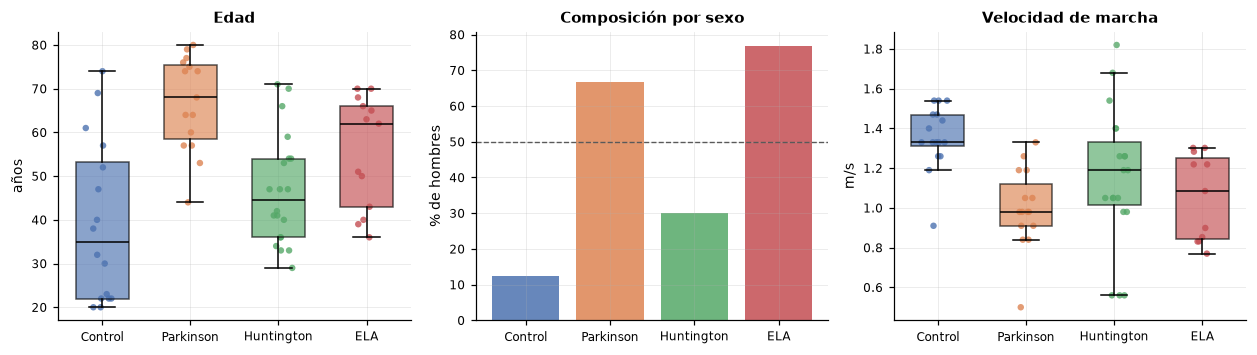

In [12]:
grupos = config.GROUP_ORDER
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.3))

plots.grouped_box(axes[0], sujetos, "age", "Edad", "años")
plots.grouped_strip(axes[0], sujetos, "age")

proporcion = sujetos.assign(hombre=sujetos.sex.eq("m")).groupby("group").hombre.mean().reindex(grupos)
axes[1].bar(range(len(grupos)), 100 * proporcion, color=plots.colors_for(grupos), alpha=0.85)
axes[1].axhline(50, color="0.35", ls="--", lw=0.9)
axes[1].set_xticks(range(len(grupos)), plots.labels_for(grupos))
axes[1].set_title("Composición por sexo")
axes[1].set_ylabel("% de hombres")

plots.grouped_box(axes[2], sujetos, "speed_ms", "Velocidad de marcha", "m/s")
plots.grouped_strip(axes[2], sujetos, "speed_ms")

fig.tight_layout()
plots.save(fig, "confusores_demograficos")

In [13]:
talla_por_sexo = sujetos.pivot_table(index="group", columns="sex", values="height_m", aggfunc="mean")
talla_por_sexo = talla_por_sexo.reindex(config.GROUP_ORDER)
talla_por_sexo.index = [config.GROUP_LABELS[g] for g in talla_por_sexo.index]
talla_por_sexo.columns = ["mujeres", "hombres"]
print(talla_por_sexo.round(3).to_string())
print()
print("sujetos con talla declarada por encima de 1.95 m:")
print(sujetos.loc[sujetos.height_m > 1.95, ["record", "group", "sex", "age", "height_m"]].to_string(index=False))

            mujeres  hombres
Control       1.821    1.915
Parkinson     1.692    1.959
Huntington    1.787    1.930
ELA           1.657    1.771

sujetos con talla declarada por encima de 1.95 m:
record group sex  age  height_m
 hunt5  hunt   m   36     2.000
 hunt7  hunt   m   71     2.000
hunt11  hunt   m   33     1.970
 park1  park   m   77     2.000
 park6  park   m   53     2.000
park11  park   m   74     2.040
park14  park   m   57     2.130
park15  park   m   76     2.000


**La talla declarada no es creíble.** La media de las mujeres del grupo control es 1.82 m y la de Huntington 1.79 m, valores imposibles para una cohorte femenina adulta. Ocho sujetos superan los 2.00 m, uno de ellos 2.13 m.

El grupo ELA es la excepción: 1.66 m en mujeres, 1.77 m en hombres —cifras plausibles— y además sus valores tienen tres decimales (1.803, 1.219) mientras los demás tienen dos. Esos decimales son la firma de una conversión desde unidades imperiales: 86.18 kg son exactamente 190 libras, 40.82 kg son 90 libras.

La conclusión es que **las tres cohortes se recolectaron por separado y con convenciones de unidades distintas**, consistente con el defecto 3. `height_m` y `weight_kg` quedan fuera del modelado: no son comparables entre grupos y cualquier señal que aporten sería señal de procedencia, no de fisiología.

---

## 7. Las series de marcha

Se pasa del nivel del sujeto al nivel de la zancada: 15 160 zancadas repartidas en 64 registros.

In [14]:
zancadas = gaitndd.read_all_strides()
print("zancadas:", f"{len(zancadas):,}", "| columnas:", zancadas.shape[1], "| registros:", zancadas.record.nunique())
zancadas.head(3)

zancadas: 15,160 | columnas: 16 | registros: 64


,record,group,stride_index,time_s,stride_left_s,stride_right_s,swing_left_s,swing_right_s,swing_left_pct,swing_right_pct,stance_left_s,stance_right_s,stance_left_pct,stance_right_pct,double_support_s,double_support_pct
0,als1,als,0,22.320,1.283,1.353,0.407,0.413,31.690,30.540,0.877,0.940,68.310,69.460,0.463,36.100
1,als1,als,1,23.643,1.323,1.267,0.483,0.400,36.520,31.580,0.840,0.867,63.480,68.420,0.440,33.250
2,als1,als,2,24.947,1.303,1.360,0.450,0.427,34.530,31.370,0.853,0.933,65.470,68.630,0.427,32.740


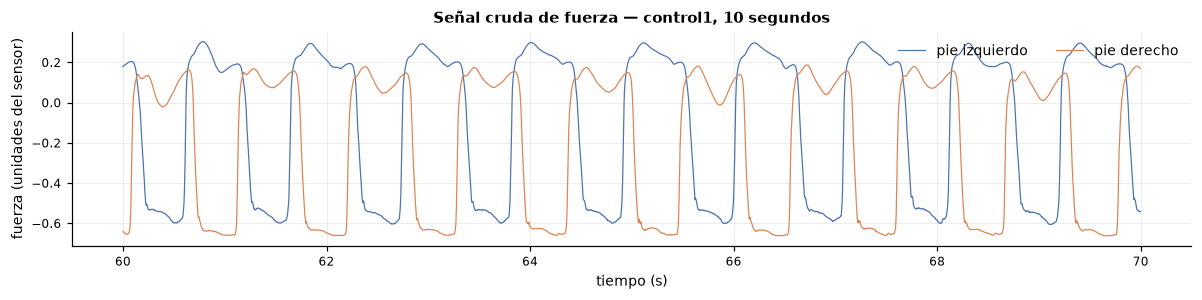

In [15]:
senal = gaitndd.read_force_signal("control1")
ventana = senal[(senal.time_s >= 60) & (senal.time_s < 70)]

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(ventana.time_s, ventana.left, lw=0.8, color="#4C72B0", label="pie izquierdo")
ax.plot(ventana.time_s, ventana.right, lw=0.8, color="#DD8452", label="pie derecho")
ax.set_title("Señal cruda de fuerza — control1, 10 segundos")
ax.set_xlabel("tiempo (s)")
ax.set_ylabel("fuerza (unidades del sensor)")
ax.legend(loc="upper right", ncols=2)
fig.tight_layout()
plots.save(fig, "senal_fuerza_cruda")

De esta señal el algoritmo original extrae los instantes de contacto y despegue de cada pie, y de ahí las 13 medidas por zancada del archivo `.ts`. El análisis trabaja sobre ese nivel derivado.

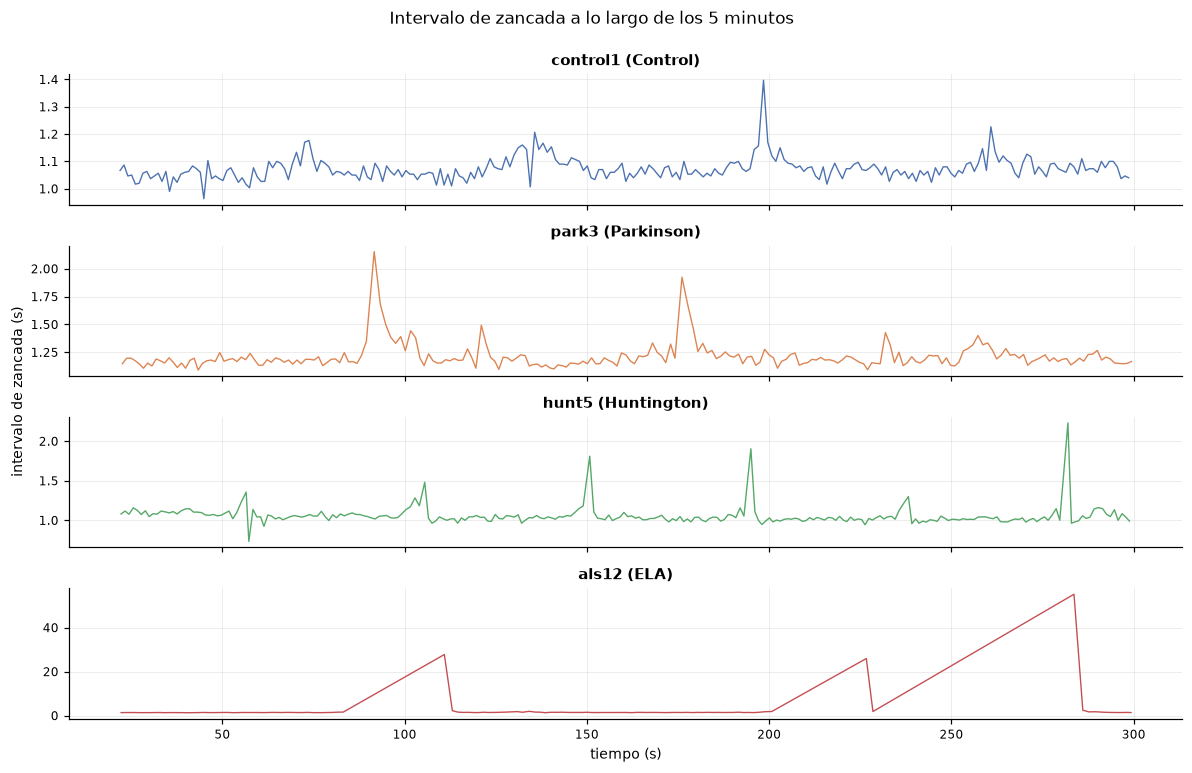

In [16]:
ejemplos = ["control1", "park3", "hunt5", "als12"]
fig, axes = plt.subplots(4, 1, figsize=(11, 7), sharex=True)
for ax, registro in zip(axes, ejemplos):
    plots.stride_series(ax, zancadas, registro)
axes[-1].set_xlabel("tiempo (s)")
fig.supylabel("intervalo de zancada (s)", fontsize=9)
fig.suptitle("Intervalo de zancada a lo largo de los 5 minutos", y=0.995)
fig.tight_layout()
plots.save(fig, "series_zancada_ejemplos")

La diferencia visual es el objeto de estudio. El control mantiene un intervalo casi constante alrededor de 1.1 s. El paciente con Parkinson tiene una base regular con excursiones ocasionales al doble de duración. El de Huntington produce picos abruptos y aislados sobre una base por lo demás estable.

El panel de ELA muestra otra cosa. Nótese la escala del eje: `als12` tiene zancadas de 27.7, 25.9 y **55.2 segundos**, contra una mediana de 1.38 s. La apariencia de rampa es solo la línea interpolando entre dos puntos separados por casi medio minuto de eje horizontal; en realidad son tres observaciones aisladas.

Lo que ocurrió se lee en la descomposición de esa zancada: en la de 27.7 s, la **fase de apoyo dura 26.6 s**. El pie izquierdo estuvo plantado en el suelo durante veintiséis segundos. El sujeto se detuvo, y el algoritmo registró la pausa como una zancada gigantesca.

Tres observaciones de 122 bastan para arruinar cualquier estadístico de dispersión del sujeto. La sección siguiente cuantifica el daño.

In [17]:
cobertura = zancadas.groupby(["group", "record"]).time_s.agg(["min", "max", "size"])
cobertura.columns = ["primera_zancada_s", "ultima_zancada_s", "n_zancadas"]
print(cobertura.groupby("group").agg(
    inicio_medio=("primera_zancada_s", "mean"),
    inicio_max=("primera_zancada_s", "max"),
    fin_min=("ultima_zancada_s", "min"),
    zancadas_media=("n_zancadas", "mean"),
    zancadas_min=("n_zancadas", "min"),
    zancadas_max=("n_zancadas", "max"),
).round(1).to_string())
print()
print("registros cuya primera zancada aparece después del segundo 25:")
print(cobertura[cobertura.primera_zancada_s > 25].round(2).to_string())

         inicio_medio  inicio_max  fin_min  zancadas_media  zancadas_min  zancadas_max
group                                                                                 
als            22.600      23.500  273.000         196.200           122           246
control        22.200      23.500  298.600         254.800           198           277
hunt           24.400      63.900  269.700         242.300           167           310
park           22.400      23.000  298.500         245.900           203           288

registros cuya primera zancada aparece después del segundo 25:
              primera_zancada_s  ultima_zancada_s  n_zancadas
group record                                                 
hunt  hunt20             63.930           299.750         238


Las series empiezan de forma consistente alrededor del segundo 22: el protocolo descarta los primeros 20 segundos, donde la marcha todavía se está estabilizando. **`hunt20` es la excepción**: su primera zancada aparece en el segundo 63.9, con 42 segundos de registro perdidos. Vuelve a aparecer en la sección siguiente, y no por casualidad.

El número de zancadas varía entre 122 y 310. Esa variación no es ruido: un sujeto que da menos zancadas en los mismos cinco minutos camina más lento. También implica que los sujetos no contribuyen la misma cantidad de datos, lo que importa al decidir la unidad de análisis.

---

## 8. Calidad de las series: qué es fisiología y qué es artefacto

Dado que las series no vienen filtradas, hay que definir explícitamente qué es una zancada válida. Se aplican tres reglas, todas derivadas de restricciones físicas y no de criterios estadísticos:

1. **Rango fisiológico.** El intervalo de zancada debe estar entre 0.5 y 2.5 s. Por debajo es imposible; por encima, la persona se detuvo, giró al final del pasillo o el sensor perdió una pisada.
2. **Apoyo doble no negativo.** El tiempo con ambos pies en el suelo no puede ser menor que cero.
3. **Porcentajes en [0, 100].** Las fases expresadas como porcentaje del ciclo no pueden salirse de ese intervalo.

Una cuarta comprobación, que `balanceo% + apoyo% = 100`, se cumple en las 15 160 zancadas: la derivación interna del dataset es consistente consigo misma. Los problemas están en la detección de pisadas, no en la aritmética.

In [18]:
revisadas = quality.stride_violations(zancadas)
conteo = quality.violation_counts(revisadas)
conteo.index = [config.GROUP_LABELS[g] for g in conteo.index]
conteo.rename(columns={
    "stride_out_of_range": "fuera_de_rango",
    "negative_double_support": "apoyo_doble_negativo",
    "percentage_out_of_bounds": "porcentaje_invalido",
    "any_violation": "alguna",
    "n_strides": "zancadas",
    "pct_any": "% afectado",
})

,fuera_de_rango,apoyo_doble_negativo,porcentaje_invalido,alguna,zancadas,% afectado
ELA,23,0,128,150,2550,5.882
Control,1,0,0,1,4076,0.025
Huntington,260,237,239,261,4846,5.386
Parkinson,13,2,5,16,3688,0.434


In [19]:
reporte = quality.record_report(revisadas)
sospechosos = quality.suspect_records(reporte)
sospechosos[["group", "record", "n_strides", "pct_violations", "left_right_ratio", "first_stride_s", "reason"]]

,group,record,n_strides,pct_violations,left_right_ratio,first_stride_s,reason
8,als,als5,205,44.390,1.008,21.953,violaciones masivas
10,als,als7,159,22.642,1.004,23.527,violaciones masivas
41,hunt,hunt20,238,100.000,43.343,63.933,canal inconsistente y violaciones masivas


El detector marca tres registros. `als5` y `als7` acumulan 44% y 23% de zancadas con porcentajes inválidos. Pero `hunt20` es de otra categoría: **el 100% de sus zancadas viola alguna regla**, y la razón mediana entre el intervalo del pie derecho y el del izquierdo es **43.3** cuando debería ser 1.

In [20]:
hunt20 = zancadas[zancadas.record == "hunt20"]
comparacion = hunt20[[
    "stride_left_s", "stride_right_s",
    "swing_left_pct", "swing_right_pct",
    "stance_left_pct", "stance_right_pct",
    "double_support_pct",
]].describe().T[["min", "50%", "max"]]
comparacion

,min,50%,max
stride_left_s,0.913,0.990,1.307
stride_right_s,19.643,42.910,58.387
swing_left_pct,31.120,38.820,51.530
swing_right_pct,1.420,2.020,3.720
stance_left_pct,48.470,61.180,68.880
stance_right_pct,96.280,97.980,98.580
double_support_pct,-70.230,-22.225,"4,317.350"


**El canal del pie derecho de `hunt20` está muerto.** Su intervalo de zancada mediano es de 42.9 s contra 0.99 s del izquierdo; la fase de apoyo derecha ocupa el 98% del ciclo y la de balanceo el 2%, cuando lo normal es 60/40. El apoyo doble resultante va de −70% a +4317% del ciclo, magnitudes sin significado físico.

El sensor derecho no registró despegues: el algoritmo interpretó los cinco minutos como un puñado de zancadas larguísimas. Sumado a que su registro empieza 42 segundos tarde, a que su velocidad de marcha es `MISSING` y a que es el sujeto cuya fila está partida en el archivo de metadata, **`hunt20` falla de cuatro maneras independientes y se excluye del análisis**. Quedan 63 sujetos y 19 en el grupo Huntington.

In [21]:
limpias = quality.drop_violations(revisadas)
limpias = limpias[limpias.record != "hunt20"]

print(f"zancadas: {len(zancadas):,} → {len(limpias):,}  ({100 * (1 - len(limpias) / len(zancadas)):.1f}% descartado)")
print(f"registros: {zancadas.record.nunique()} → {limpias.record.nunique()}")
print()
print(pd.DataFrame({
    "antes": zancadas.groupby("group").size(),
    "después": limpias.groupby("group").size(),
}).assign(descartado_pct=lambda d: 100 * (1 - d["después"] / d["antes"])).round(2).to_string())

zancadas: 15,160 → 14,732  (2.8% descartado)
registros: 64 → 63

         antes  después  descartado_pct
group                                  
als       2550     2400           5.880
control   4076     4075           0.020
hunt      4846     4585           5.390
park      3688     3672           0.430


### 8.1 El filtrado cambia la conclusión, no solo los números

El coeficiente de variación del intervalo de zancada es el marcador clásico de inestabilidad de la marcha. Vale la pena calcularlo antes y después de aplicar las reglas.

In [22]:
sin_filtrar = features.build_feature_table(zancadas[zancadas.record != "hunt20"])
filtradas = features.build_feature_table(limpias)

efecto = pd.DataFrame({
    "CV sin filtrar": sin_filtrar.groupby("group").stride_cv.mean(),
    "CV filtrado": filtradas.groupby("group").stride_cv.mean(),
}).reindex(config.GROUP_ORDER)
efecto["factor"] = efecto["CV sin filtrar"] / efecto["CV filtrado"]
efecto.index = [config.GROUP_LABELS[g] for g in efecto.index]
efecto

,CV sin filtrar,CV filtrado,factor
Control,0.044,0.041,1.077
Parkinson,0.189,0.074,2.559
Huntington,0.138,0.105,1.316
ELA,0.431,0.063,6.804


Este es el hallazgo central del análisis de calidad.

Sin filtrar, el grupo **ELA exhibe un CV de 0.43, diez veces el de los controles**, y cualquiera concluiría que la ELA produce la marcha más inestable de las tres patologías. Después de descartar el 5.9% de zancadas inválidas del grupo —23 de ellas fuera de todo rango fisiológico, con duraciones de hasta 55 segundos— ese CV cae a **0.063**, apenas un 50% por encima del control.

La variabilidad aparente de la ELA era casi enteramente **artefacto de medición**. Un puñado de zancadas de hasta 55 segundos dominaba la desviación estándar del grupo. El Parkinson recorre el mismo camino con menor dramatismo: de 0.19 a 0.074.

Con los datos limpios el orden se invierte y el grupo más inestable es **Huntington** (CV 0.105), lo que sí es consistente con la fisiopatología coreica. La lección metodológica es que en este dataset **la decisión de filtrado no ajusta los resultados: los determina**.

### 8.2 La tensión que el filtrado no resuelve

Descartar zancadas tiene un costo que hay que declarar. Las reglas eliminan 260 zancadas del grupo Huntington y solo 1 del grupo control: el filtrado es **diferencial por clase**, y necesariamente lo es, porque la marcha patológica genera más fallos de detección que la sana.

Eso abre una pregunta que no se puede cerrar con los datos disponibles: una zancada de 3 segundos en un paciente con Huntington, ¿es un error del sensor o un episodio de congelamiento real? Si es lo segundo, el filtro está borrando precisamente la señal clínica de interés.

Por eso el criterio adoptado es **conservador**: se aplica solo el rango fisiológico y las reglas de consistencia interna, y **no** se aplica el filtro por dispersión robusta (mediana ± 4 MAD), que eliminaría otras 324 zancadas seleccionadas por ser estadísticamente atípicas dentro de cada sujeto. Ese segundo filtro borraría variabilidad real. La sensibilidad de los resultados a esta decisión se reporta en P2.

In [23]:
print("zancadas que descartaría adicionalmente el filtro por dispersión (mediana ± 4 MAD):")
print(revisadas[~revisadas.any_violation].groupby("group").dispersion_outlier.sum().to_string())

zancadas que descartaría adicionalmente el filtro por dispersión (mediana ± 4 MAD):
group
als         47
control    112
hunt        68
park        97


---

## 9. ¿Hay señal a nivel de sujeto?

De cada serie limpia se extraen descriptores que resumen tres aspectos distintos de la marcha:

| Familia | Descriptores | Qué captura |
|---|---|---|
| Ritmo | `stride_mean`, `cadence_strides_per_min` | Qué tan rápido y con qué paso camina |
| Dispersión | `stride_cv`, `stride_sd`, `stride_iqr` | Cuánto varía de una zancada a la siguiente |
| Simetría | `asymmetry_stride`, `asymmetry_swing` | Cuánto difiere un lado del otro |
| Estructura temporal | `autocorr_lag1`, `dfa_alpha` | Si la variabilidad tiene memoria o es ruido blanco |

El exponente de *detrended fluctuation analysis* (`dfa_alpha`) merece una nota: mide si las fluctuaciones del intervalo de zancada están correlacionadas a largo plazo. En marcha sana vale alrededor de 0.85, señal de un control motor con memoria; un valor cercano a 0.5 indica que la serie se volvió ruido blanco, es decir, que el sistema perdió esa regulación.

In [24]:
descriptores = [
    "stride_mean", "stride_cv", "double_support_pct_mean",
    "asymmetry_stride", "autocorr_lag1", "dfa_alpha",
]
tabla = filtradas.groupby("group")[descriptores].mean().reindex(config.GROUP_ORDER)
tabla.index = [config.GROUP_LABELS[g] for g in tabla.index]
tabla

,stride_mean,stride_cv,double_support_pct_mean,asymmetry_stride,autocorr_lag1,dfa_alpha
Control,1.097,0.041,28.213,0.035,0.486,0.875
Parkinson,1.125,0.074,34.030,0.157,0.322,0.805
Huntington,1.152,0.105,31.975,0.258,0.190,0.653
ELA,1.356,0.063,35.318,0.114,0.434,0.850


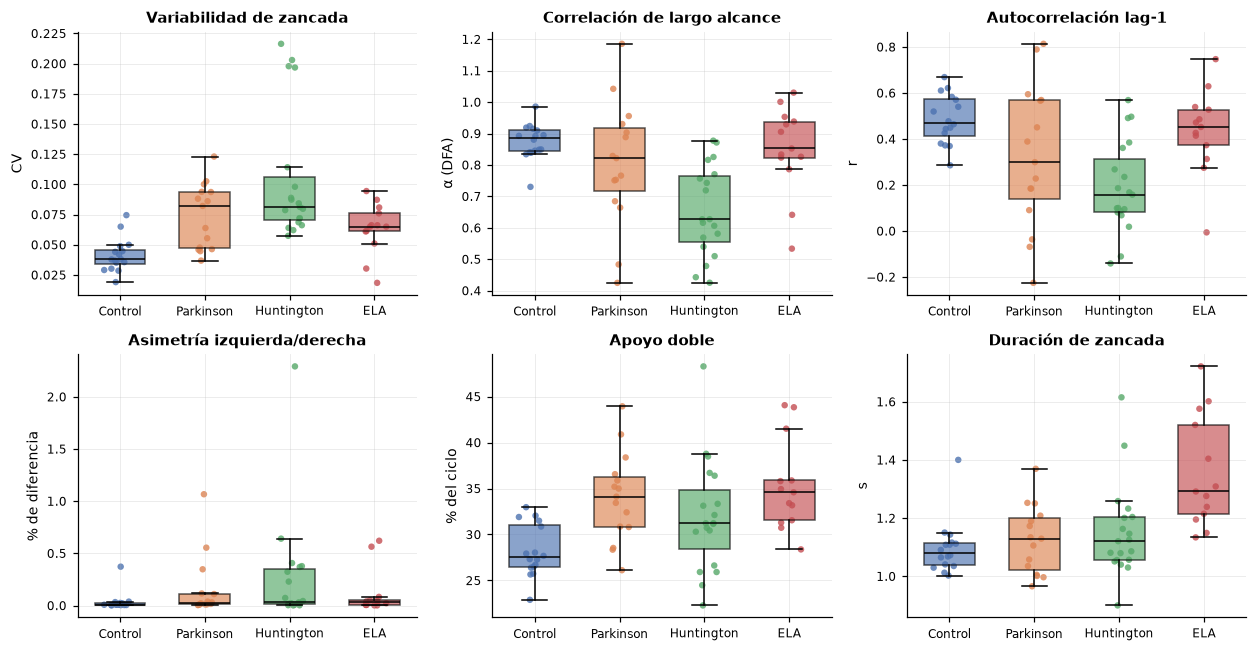

In [25]:
titulos = {
    "stride_cv": ("Variabilidad de zancada", "CV"),
    "dfa_alpha": ("Correlación de largo alcance", "α (DFA)"),
    "autocorr_lag1": ("Autocorrelación lag-1", "r"),
    "asymmetry_stride": ("Asimetría izquierda/derecha", "% de diferencia"),
    "double_support_pct_mean": ("Apoyo doble", "% del ciclo"),
    "stride_mean": ("Duración de zancada", "s"),
}

fig, axes = plt.subplots(2, 3, figsize=(11.5, 6))
for ax, (columna, (titulo, unidad)) in zip(axes.ravel(), titulos.items()):
    plots.grouped_box(ax, filtradas, columna, titulo, unidad)
    plots.grouped_strip(ax, filtradas, columna)
fig.tight_layout()
plots.save(fig, "descriptores_por_grupo")

Los descriptores se ordenan de manera coherente con la clínica de cada patología.

**Huntington** pierde estructura temporal: su α de DFA cae a 0.65 y la autocorrelación lag-1 a 0.19, contra 0.88 y 0.49 en controles. Su marcha no solo es más variable, es variable *sin memoria* —exactamente lo que se esperaría de un sistema de control motor desregulado por corea. Es además el grupo más asimétrico.

**ELA** presenta la zancada más larga (1.36 s contra 1.10 s del control) y el mayor porcentaje de apoyo doble (35.3% contra 28.2%). El patrón es de compensación: pasos lentos y más tiempo con ambos pies en el suelo, la estrategia esperable ante debilidad muscular progresiva.

**Parkinson** queda en una posición intermedia en casi todo, lo que anticipa que será la clase más difícil de separar.

Ningún descriptor aislado separa las cuatro clases: todas las cajas se solapan. La señal, si existe, es multivariada.

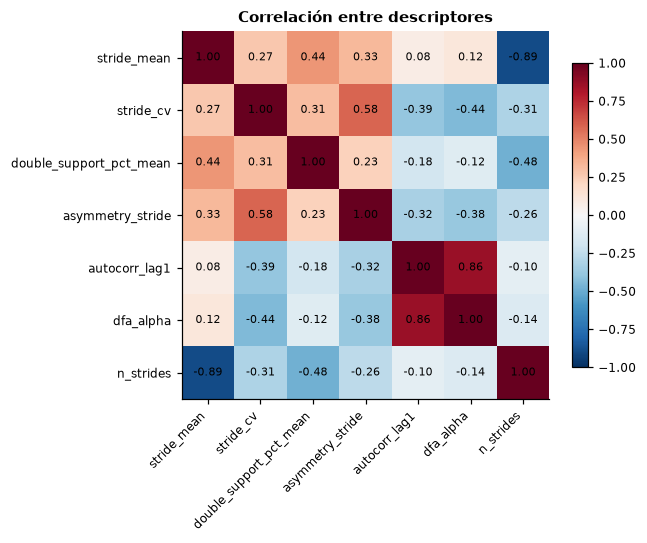

In [26]:
matriz = filtradas[descriptores + ["n_strides"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
imagen = ax.imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz)), matriz.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz)), matriz.columns)
for i in range(len(matriz)):
    for j in range(len(matriz)):
        ax.text(j, i, f"{matriz.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlación entre descriptores")
ax.grid(False)
fig.colorbar(imagen, ax=ax, shrink=0.8)
fig.tight_layout()
plots.save(fig, "correlacion_descriptores")

`stride_mean` y `n_strides` están correlacionados en −0.99: son la misma información expresada de dos formas, porque en una ventana de duración fija el número de zancadas es el inverso de su duración. Una de las dos es redundante. `autocorr_lag1` y `dfa_alpha` correlacionan en torno a 0.8, lo esperable ya que ambas miden persistencia temporal, aunque a escalas distintas.

### 9.1 ¿Descriptores de marcha o confusores disfrazados? (RQ3)

La prueba que importa: ¿cuánto de lo que miden estos descriptores es patología y cuánto es edad o velocidad?

In [27]:
unido = filtradas.merge(sujetos[["record", "age", "speed_ms", "sex"]], on="record")
confusores = unido[descriptores].corrwith(unido.age).to_frame("r con edad")
confusores["r con velocidad"] = unido[descriptores].corrwith(unido.speed_ms)
confusores.round(3)

,r con edad,r con velocidad
stride_mean,0.191,-0.475
stride_cv,0.137,-0.528
double_support_pct_mean,0.373,-0.637
asymmetry_stride,0.246,-0.344
autocorr_lag1,-0.271,0.086
dfa_alpha,-0.183,0.127


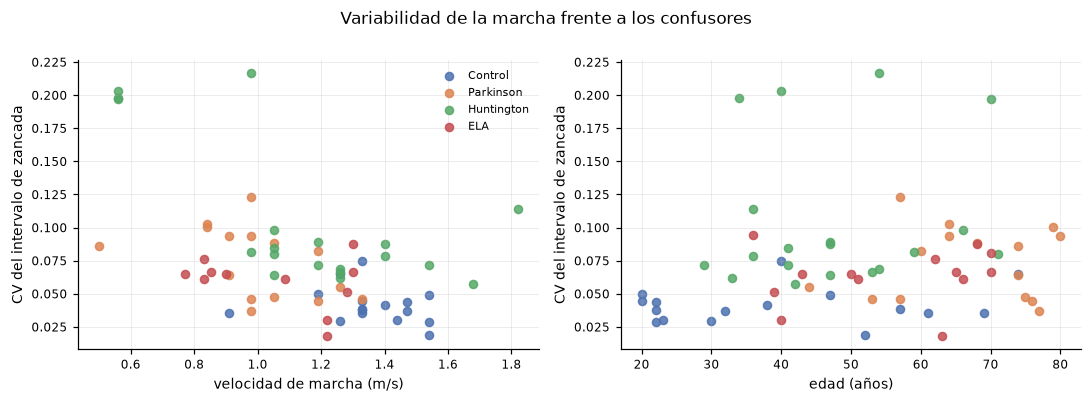

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (x, etiqueta) in zip(axes, [("speed_ms", "velocidad de marcha (m/s)"), ("age", "edad (años)")]):
    for grupo in config.GROUP_ORDER:
        sub = unido[unido.group == grupo]
        ax.scatter(sub[x], sub.stride_cv, s=28, alpha=0.85,
                   color=config.GROUP_COLORS[grupo], label=config.GROUP_LABELS[grupo])
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("CV del intervalo de zancada")
axes[0].legend(loc="upper right", fontsize=7)
fig.suptitle("Variabilidad de la marcha frente a los confusores", y=1.0)
fig.tight_layout()
plots.save(fig, "confusores_vs_variabilidad")

La velocidad de marcha correlaciona con todos los descriptores: −0.64 con el porcentaje de apoyo doble, −0.53 con la variabilidad y −0.48 con la duración de zancada. Parte de eso es mecánico —quien camina más rápido da zancadas más cortas y pasa menos tiempo con ambos pies en el suelo—. La edad correlaciona de forma más débil (máximo 0.37).

El gráfico muestra lo importante: **dentro de cada color la relación entre velocidad y variabilidad es plana**. La velocidad separa los grupos porque los pacientes caminan más lento, pero no explica por sí sola la variabilidad dentro de un grupo. Eso sugiere que los descriptores de dispersión y de estructura temporal aportan información propia.

Aun así, la conclusión de P1 sobre RQ3 es cautelosa: **la edad y el sexo no son controlables con este diseño**. El grupo control es 27 años más joven y mayoritariamente femenino. Cualquier desempeño reportado incluye una componente demográfica que este dataset no permite separar, y así se declarará en las limitaciones del paper.

---

## 10. El problema de fuga de información (RQ2)

Sesenta y tres sujetos son pocos para entrenar. La tentación —y la práctica habitual en la literatura sobre este dataset— es trocear la serie de cada sujeto en ventanas y tratar cada ventana como una observación independiente. Eso multiplica las filas por ocho.

Pero las ventanas del mismo sujeto **no son independientes**: comparten fisiología, calzado, sesión, altura y longitud de pierna. Si una partición aleatoria deja unas ventanas de un sujeto en entrenamiento y otras en prueba, el modelo puede reconocer al individuo en lugar de la enfermedad.

La magnitud del efecto se puede medir.

In [29]:
ventanas = features.window_features(limpias, window_strides=30)
print(f"ventanas: {len(ventanas)}   sujetos: {ventanas.record.nunique()}")
print()
print(ventanas.group.value_counts().reindex(config.GROUP_ORDER).to_string())

ventanas: 482   sujetos: 63

group
control    133
park       120
hunt       150
als         79


In [30]:
predictores = [c for c in ventanas.columns if c not in ("group", "record", "window_index", "observed_span_s")]
X = ventanas[predictores].to_numpy()
y = ventanas.group.to_numpy()
sujeto = ventanas.record.to_numpy()

bosque = RandomForestClassifier(n_estimators=300, random_state=config.RANDOM_STATE, n_jobs=-1)

aleatorio = cross_val_score(
    bosque, X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=config.RANDOM_STATE),
    scoring="balanced_accuracy",
)
agrupado = cross_val_score(
    bosque, X, y, groups=sujeto,
    cv=StratifiedGroupKFold(5, shuffle=True, random_state=config.RANDOM_STATE),
    scoring="balanced_accuracy",
)

por_sujeto = cross_val_score(
    bosque,
    filtradas[predictores].to_numpy(), filtradas.group.to_numpy(),
    cv=StratifiedKFold(5, shuffle=True, random_state=config.RANDOM_STATE),
    scoring="balanced_accuracy",
)

pd.DataFrame({
    "unidad": ["ventana de 30 zancadas", "ventana de 30 zancadas", "sujeto"],
    "partición": ["aleatoria", "por sujeto", "estratificada"],
    "n": [len(ventanas), len(ventanas), len(filtradas)],
    "balanced accuracy": [aleatorio.mean(), agrupado.mean(), por_sujeto.mean()],
    "desviación": [aleatorio.std(), agrupado.std(), por_sujeto.std()],
}).set_index(["unidad", "partición"])

n  balanced accuracy  desviación
unidad                 partición                                        
ventana de 30 zancadas aleatoria      482              0.812       0.049
                       por sujeto     482              0.622       0.086
sujeto                 estratificada   63              0.642       0.048

**La partición aleatoria infla la balanced accuracy en 19 puntos porcentuales**: 0.81 contra 0.62 con exactamente los mismos datos, los mismos descriptores y el mismo modelo. La única diferencia es si las ventanas de un sujeto pueden aparecer a ambos lados de la partición.

La verificación decisiva es la tercera fila. Evaluando directamente a nivel de sujeto —63 observaciones, sin ventanas y sin posibilidad de fuga— se obtiene **0.64**, un valor que coincide con la estimación agrupada (0.62) y no con la aleatoria (0.81). Esto confirma que el split agrupado es el estimador correcto y que los 19 puntos de diferencia son optimismo puro, no una ventaja real de usar más filas.

Este experimento no es el modelo del proyecto: es un diagnóstico. Fija dos requisitos innegociables para P2:

1. Toda validación debe agrupar por sujeto (`StratifiedGroupKFold` o *leave-one-subject-out*).
2. La búsqueda de hiperparámetros debe ocurrir **dentro** del bucle de validación, no antes, o reintroduce la misma fuga por otra puerta.

Como referencia, el azar en cuatro clases balanceadas da 0.25. El 0.62 honesto está muy por encima, así que hay señal real —solo que bastante menos espectacular de lo que sugeriría el número inflado.

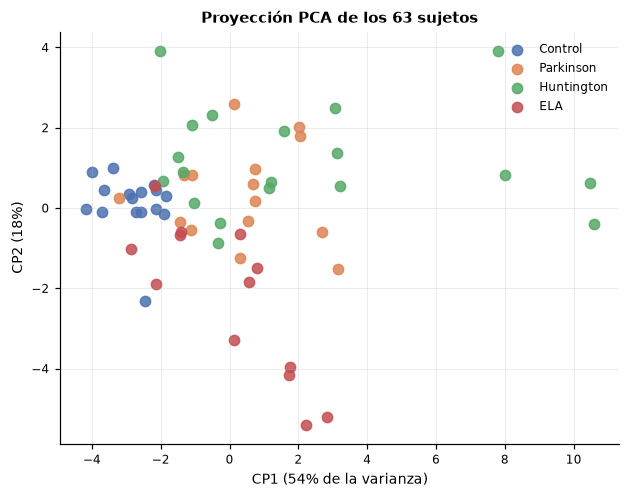

In [31]:
escalado = StandardScaler().fit_transform(filtradas[predictores])
proyeccion = PCA(n_components=2, random_state=config.RANDOM_STATE).fit(escalado)
coordenadas = proyeccion.transform(escalado)

fig, ax = plt.subplots(figsize=(5.8, 4.6))
for grupo in config.GROUP_ORDER:
    mascara = (filtradas.group == grupo).to_numpy()
    ax.scatter(coordenadas[mascara, 0], coordenadas[mascara, 1], s=45, alpha=0.85,
               color=config.GROUP_COLORS[grupo], label=config.GROUP_LABELS[grupo])
ax.set_xlabel(f"CP1 ({100 * proyeccion.explained_variance_ratio_[0]:.0f}% de la varianza)")
ax.set_ylabel(f"CP2 ({100 * proyeccion.explained_variance_ratio_[1]:.0f}%)")
ax.set_title("Proyección PCA de los 63 sujetos")
ax.legend(fontsize=8)
fig.tight_layout()
plots.save(fig, "pca_sujetos")

Las dos primeras componentes retienen el 72% de la varianza (54.5% y 17.6%) y muestran una estructura parcial: los controles se concentran en una región y los casos de Huntington se dispersan hacia el extremo opuesto, pero Parkinson y ELA se superponen con todo lo demás. Es la representación visual de lo que anticipa el 0.62: señal real, clases no separables linealmente en dos dimensiones.

---

## 11. Síntesis

**Sobre los datos.** El dataset tiene 64 sujetos y cuatro clases desbalanceadas (16/15/20/13). Su metadata exige un parser propio: un salto de línea rompe un registro, los faltantes son la cadena `MISSING`, la columna de grupo etiqueta mal a los 13 sujetos con ELA y la de severidad mezcla tres escalas incomparables que además filtran la etiqueta. Las tallas declaradas son implausibles para tres de los cuatro grupos, evidencia de que las cohortes se recolectaron por separado.

**Sobre la calidad de la señal.** Las series no están filtradas y contienen zancadas de hasta 55 segundos. Filtrarlas no es un ajuste cosmético: sin filtrar, la ELA parece la patología con la marcha más inestable (CV 0.43); filtrada, esa variabilidad se reduce a 0.063 y el grupo más inestable pasa a ser Huntington. El sujeto `hunt20` tiene el canal derecho inutilizable y se excluye.

**Sobre la señal disponible (RQ1).** Los descriptores se ordenan de forma clínicamente coherente —Huntington pierde estructura temporal, ELA compensa con zancadas largas y más apoyo doble, Parkinson queda en medio— pero ninguno separa las clases por sí solo. La separabilidad es multivariada y parcial.

**Sobre la evaluación (RQ2).** Particionar aleatoriamente ventanas del mismo sujeto infla la balanced accuracy de 0.62 a 0.81. Toda la validación de P2 se agrupará por sujeto.

**Sobre los confusores (RQ3).** El grupo control es 27 años más joven y mayoritariamente femenino frente a los grupos patológicos. Este sesgo no es corregible con el diseño del dataset y limita la interpretación causal de cualquier resultado.

## 12. Siguientes pasos para P2

1. **Validación externa con `gaitpdb`.** La segunda cohorte de PhysioNet aporta 93 pacientes con Parkinson y 73 controles capturados con otro protocolo (16 sensores por pie, 100 Hz). Permite comprobar si el eje Parkinson–control generaliza fuera de la cohorte de entrenamiento, y su registro de UPDRS habilita una tarea secundaria de regresión de severidad.
2. **Baselines explícitos.** Clasificador trivial por clase mayoritaria, y un baseline clínico que use únicamente la velocidad de marcha. Si los descriptores de dinámica no superan a la velocidad sola, no justifican su complejidad.
3. **Al menos dos familias de modelos** sobre los descriptores por sujeto (regresión logística multinomial regularizada y un ensamble de árboles), más una CNN 1D sobre la serie cruda de intervalos como tercer enfoque.
4. **Protocolo de evaluación.** *Leave-one-subject-out* dada la n reducida, con búsqueda de hiperparámetros anidada y reporte de intervalos de confianza por bootstrap sobre sujetos.
5. **Análisis de confusores.** Reentrenar restringiendo a los subgrupos comparables por edad y reportar cuánto desempeño se pierde, como cota del efecto demográfico.
6. **Interpretación.** Importancia por permutación agrupada por sujeto y análisis de la matriz de confusión, con atención a la separación Parkinson–ELA, que es la más problemática.